# Heart Disease Prediction — Full Pipeline (Colab)

### What this notebook does:
1. Upload CSV → 2. EDA + Visualizations → 3. Clean Data → 4. Train Raw RF (baseline) → 5. PCA + GridSearchCV (5 models) → 6. Compare & Deploy Best

---
**Author:** Team Zav
**Course:** Machine Learning  
**Dataset:** UCI Heart Disease (918 rows, 12 columns)

## Step 1: Import Libraries
Loads all required packages: pandas, numpy, sklearn, matplotlib, seaborn.

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('All libraries imported successfully')

All libraries imported successfully


## Step 2: Upload Dataset
Upload your `heart.csv` file using the Colab file picker.

In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f'Loaded: {filename}')
print(f'Shape: {df.shape}')
df.head()

Saving heart.csv to heart.csv
Loaded: heart.csv
Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Step 3: Check Missing Values & Duplicates
Checks if any data is missing or duplicated. Clean data = reliable model.

In [3]:
print('='*50)
print('MISSING VALUES CHECK')
print('='*50)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found! Dataset is clean.')

print(f'\nDUPLICATE ROWS: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'Removed duplicates. New shape: {df.shape}')
else:
    print('No duplicates found. Shape unchanged:', df.shape)

MISSING VALUES CHECK
No missing values found! Dataset is clean.

DUPLICATE ROWS: 0
No duplicates found. Shape unchanged: (918, 12)


## Step 4: EDA — Target Distribution
**What it shows:** Balance of HeartDisease (1) vs No Disease (0).  
**Why it matters:** Imbalanced data hurts model performance. We check if both classes have enough samples.

TARGET DISTRIBUTION
No Disease (0): 410 (44.7%)
Disease    (1): 508 (55.3%)
Ratio: 0.81:1 (balanced if close to 1)


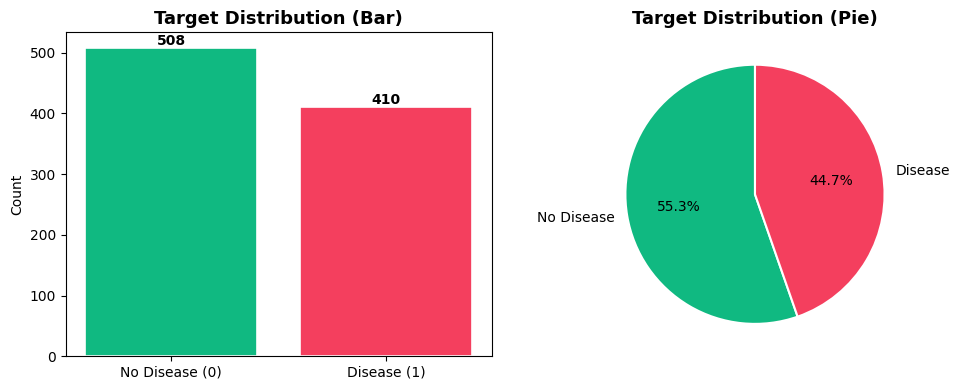

In [4]:
print('='*50)
print('TARGET DISTRIBUTION')
print('='*50)
counts = df['HeartDisease'].value_counts()
print(f'No Disease (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Disease    (1): {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print(f'Ratio: {counts[0]/counts[1]:.2f}:1 (balanced if close to 1)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#10b981', '#f43f5e']
target_counts = df['HeartDisease'].value_counts()

axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
            color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Target Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Distribution (Pie)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: EDA — Feature Distributions
**What it shows:** Histograms of Age, RestingBP, Cholesterol, MaxHR, Oldpeak.  
**Why it matters:** Reveals data spread, skewness, and extreme values that may need treatment.

NUMERICAL FEATURE SUMMARY
          Age  RestingBP  Cholesterol   MaxHR  Oldpeak
count  918.00     918.00       918.00  918.00   918.00
mean    53.51     132.40       198.80  136.81     0.89
std      9.43      18.51       109.38   25.46     1.07
min     28.00       0.00         0.00   60.00    -2.60
25%     47.00     120.00       173.25  120.00     0.00
50%     54.00     130.00       223.00  138.00     0.60
75%     60.00     140.00       267.00  156.00     1.50
max     77.00     200.00       603.00  202.00     6.20


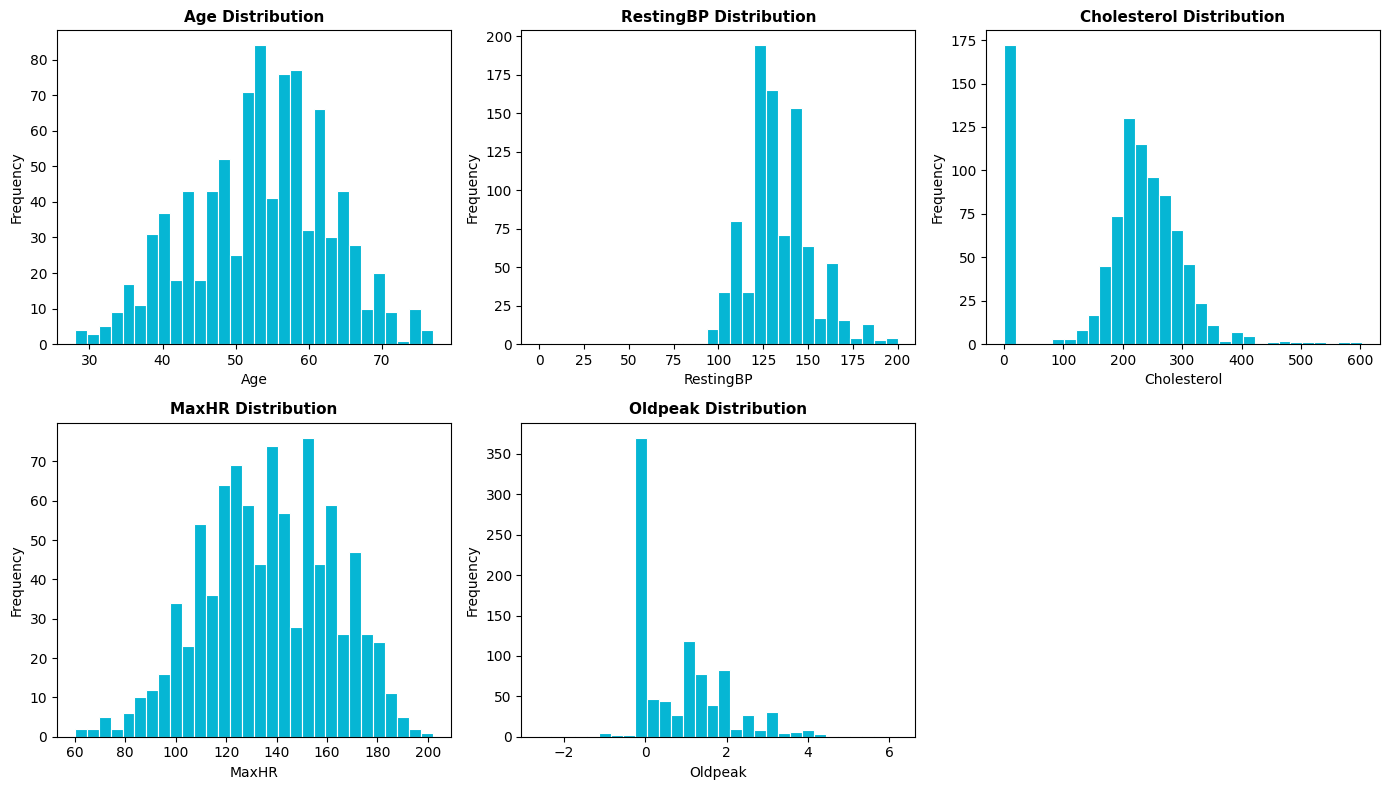

In [5]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

print('='*50)
print('NUMERICAL FEATURE SUMMARY')
print('='*50)
print(df[num_cols].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#06b6d4', edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: EDA — Box Plots (Outlier Detection)
**What it shows:** Box plots with median, quartiles, and outliers (points beyond whiskers).  
**Why it matters:** Visualizes which columns have extreme values that will be removed in Step 8.

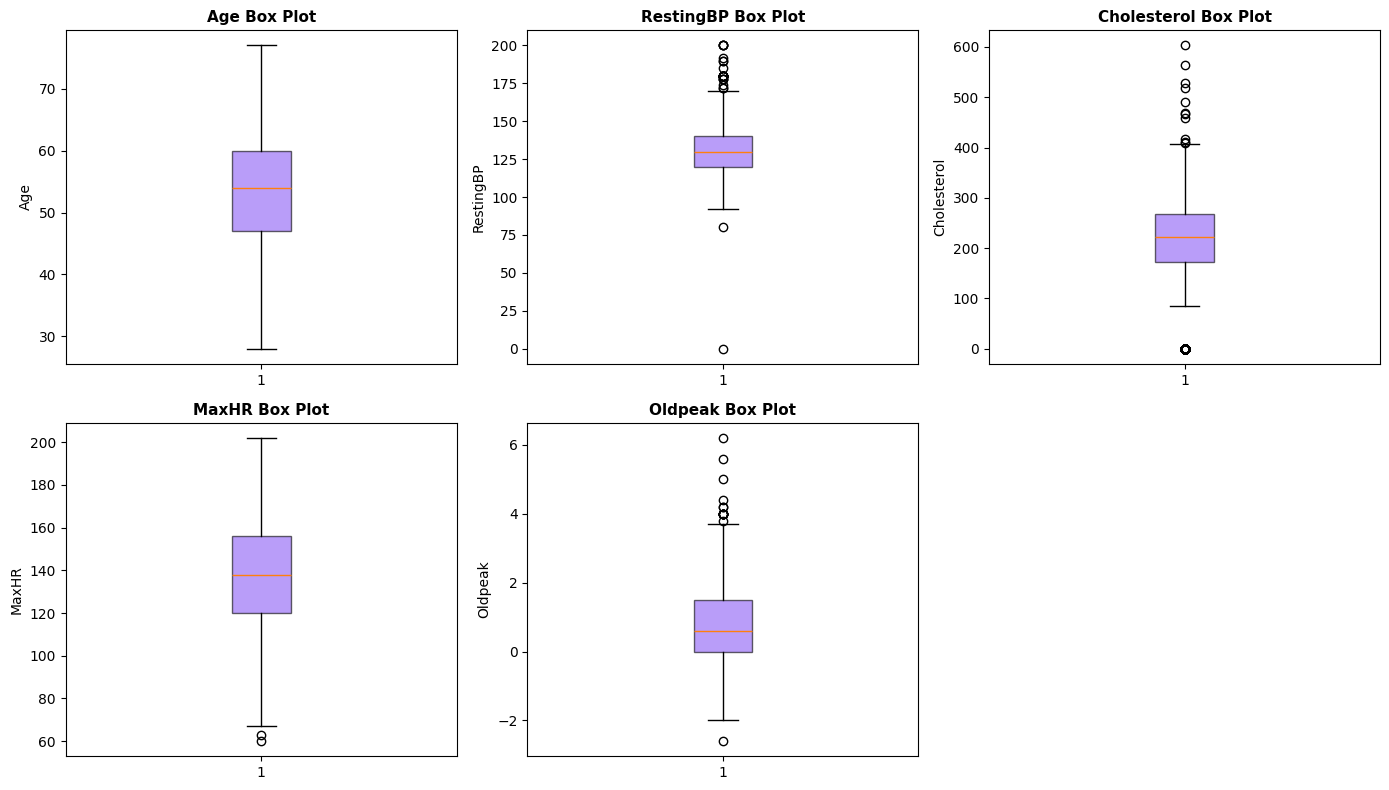

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#8b5cf6', alpha=0.6))
    axes[i].set_title(f'{col} Box Plot', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: EDA — Categorical Distributions
**What it shows:** Frequency of each category in Sex, ChestPainType, FastingBS, RestingECG, ExerciseAngina, ST_Slope.  
**Why it matters:** Understands data composition before one-hot encoding.

CATEGORICAL FEATURE SUMMARY

Sex:
  M: 725 (79.0%)
  F: 193 (21.0%)

ChestPainType:
  ASY: 496 (54.0%)
  NAP: 203 (22.1%)
  ATA: 173 (18.8%)
  TA: 46 (5.0%)

FastingBS:
  0: 704 (76.7%)
  1: 214 (23.3%)

RestingECG:
  Normal: 552 (60.1%)
  LVH: 188 (20.5%)
  ST: 178 (19.4%)

ExerciseAngina:
  N: 547 (59.6%)
  Y: 371 (40.4%)

ST_Slope:
  Flat: 460 (50.1%)
  Up: 395 (43.0%)
  Down: 63 (6.9%)


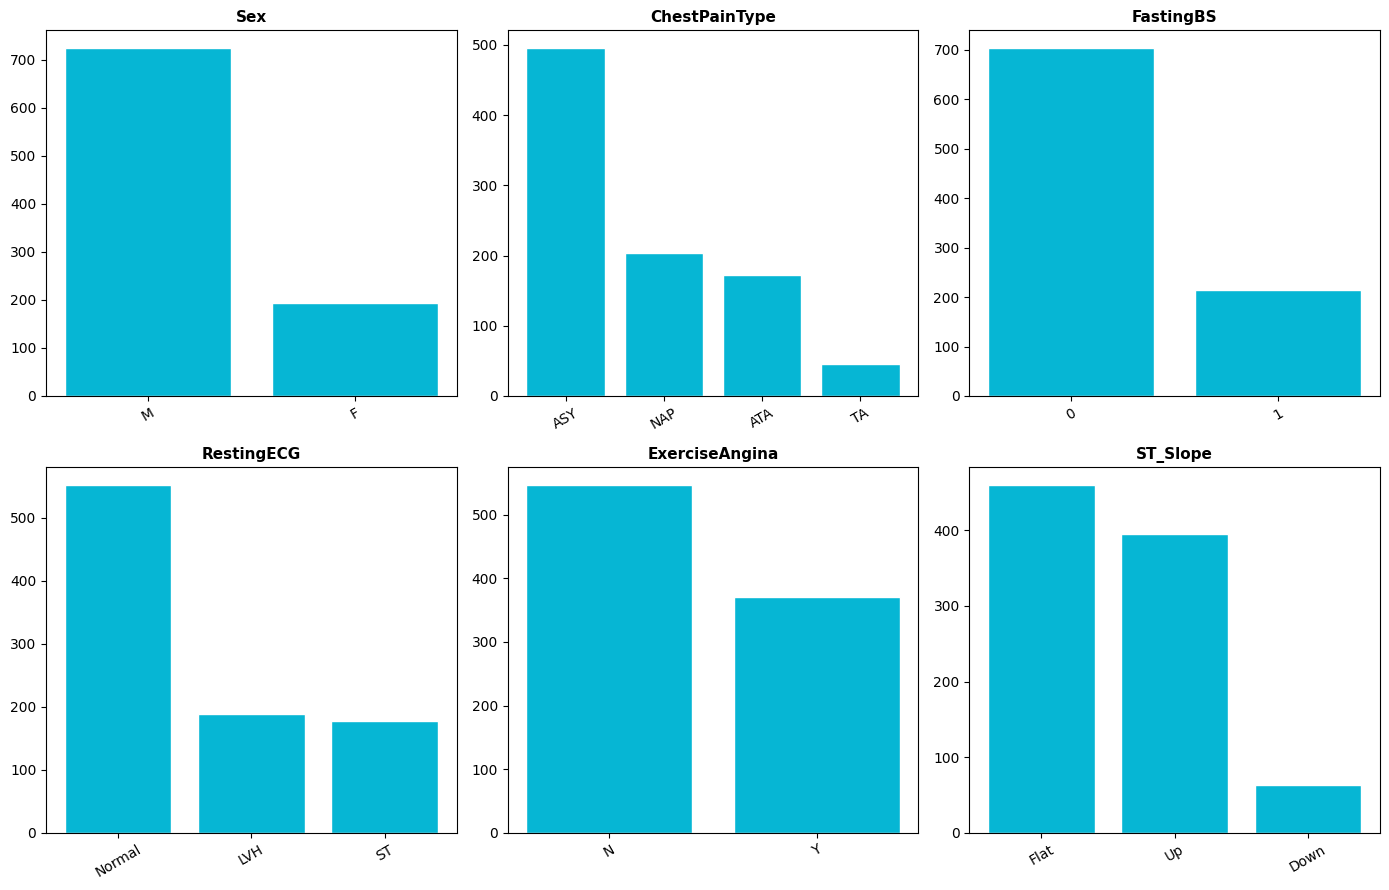

In [7]:
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

print('='*50)
print('CATEGORICAL FEATURE SUMMARY')
print('='*50)
for col in cat_cols:
    print(f'\n{col}:')
    for val, cnt in df[col].value_counts().items():
        print(f'  {val}: {cnt} ({cnt/len(df)*100:.1f}%)')

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='#06b6d4', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: EDA — Correlation Heatmap
**What it shows:** How features correlate with each other and the target.  
**Why it matters:** Identifies redundant features (high correlation between inputs) and important predictors (high correlation with target).

TOP FEATURES CORRELATED WITH TARGET
  ST_Slope: -0.559 (negative)
  ExerciseAngina: +0.494 (positive)
  Oldpeak: +0.404 (positive)
  MaxHR: -0.400 (negative)
  Age: +0.282 (positive)
  FastingBS: +0.267 (positive)
  Cholesterol: -0.233 (negative)
  RestingBP: +0.108 (positive)
  RestingECG: +0.061 (positive)


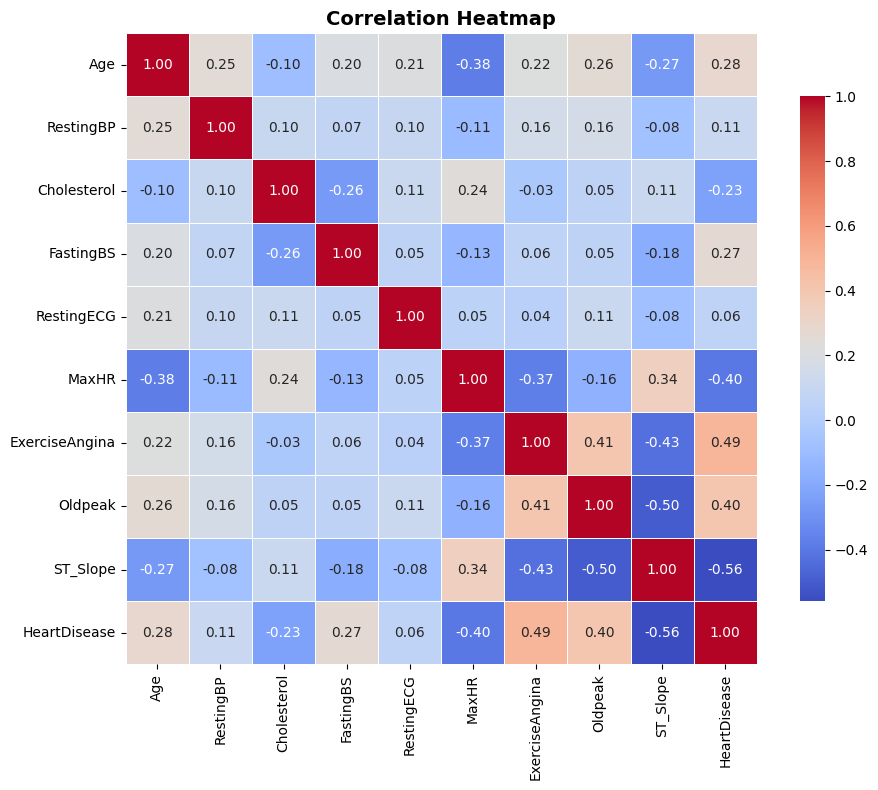

In [8]:
tmp = df.copy()
tmp['ExerciseAngina'] = tmp['ExerciseAngina'].map({'N': 0, 'Y': 1})
tmp['ST_Slope'] = tmp['ST_Slope'].map({'Down': 1, 'Flat': 2, 'Up': 3})
tmp['RestingECG'] = tmp['RestingECG'].map({'Normal': 1, 'ST': 2, 'LVH': 3})

corr = tmp.select_dtypes(include=[np.number]).corr()

print('='*50)
print('TOP FEATURES CORRELATED WITH TARGET')
print('='*50)
target_corr = corr['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    direction = 'positive' if val > 0 else 'negative'
    print(f'  {feat}: {val:+.3f} ({direction})')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Data Preprocessing
**What happens:**  
1. Remove outliers (3-sigma rule for Cholesterol, Oldpeak, RestingBP)  
2. Label encode (ExerciseAngina, ST_Slope, RestingECG)  
3. One-hot encode (Sex, ChestPainType with drop_first)  
4. Split into X (features) and y (target)

In [9]:
print('='*50)
print('OUTLIER REMOVAL (3-SIGMA)')
print('='*50)
print(f'Before: {df.shape}')
for col in ['Cholesterol', 'Oldpeak', 'RestingBP']:
    mean, std = df[col].mean(), df[col].std()
    before = len(df)
    df = df[df[col] <= (mean + 3 * std)]
    removed = before - len(df)
    print(f'  {col}: removed {removed} rows (mean={mean:.1f}, 3-sigma upper={mean+3*std:.1f})')
df = df.reset_index(drop=True)
print(f'After: {df.shape}')

print('\n' + '='*50)
print('ENCODING')
print('='*50)
df['ExerciseAngina'] = df['ExerciseAngina'].map({'N': 0, 'Y': 1})
df['ST_Slope'] = df['ST_Slope'].map({'Down': 1, 'Flat': 2, 'Up': 3})
df['RestingECG'] = df['RestingECG'].map({'Normal': 1, 'ST': 2, 'LVH': 3})
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType'], drop_first=True)
for col in df_encoded.select_dtypes('bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

feature_names = list(X.columns)
print(f'\nFinal features ({len(feature_names)}): {feature_names}')
print(f'X shape: {X.shape}, y distribution: {y.value_counts().to_dict()}')

OUTLIER REMOVAL (3-SIGMA)
Before: (918, 12)
  Cholesterol: removed 3 rows (mean=198.8, 3-sigma upper=527.0)
  Oldpeak: removed 6 rows (mean=0.9, 3-sigma upper=4.1)
  RestingBP: removed 7 rows (mean=132.3, 3-sigma upper=187.8)
After: (902, 12)

ENCODING

Final features (13): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA']
X shape: (902, 13), y distribution: {1: 495, 0: 407}


## Step 10: Train/Test Split
Splits data into 80% training and 20% testing (random_state=42 for reproducibility).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set:   {X_train.shape} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing set:    {X_test.shape} ({len(X_test)/len(X)*100:.0f}%)')

Training set:   (721, 13) (80%)
Testing set:    (181, 13) (20%)


## Step 11: Track A — Raw 13 Features (Baseline)
**Model:** RandomForest on original data (no scaling, no PCA).  
**Why:** RandomForest handles raw features well. This gives us a baseline accuracy to compare PCA against.

In [11]:
print('='*60)
print('TRACK A: RAW 13 FEATURES — RANDOMFOREST')
print('='*60)

rf_raw = RandomForestClassifier(random_state=42)
rf_raw.fit(X_train, y_train)
y_pred_raw = rf_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)
prec_raw = precision_score(y_test, y_pred_raw, average='weighted')
rec_raw = recall_score(y_test, y_pred_raw, average='weighted')
f1_raw = f1_score(y_test, y_pred_raw, average='weighted')

print(f'\nAccuracy : {acc_raw:.4f} ({acc_raw*100:.2f}%)')
print(f'Precision: {prec_raw:.4f} ({prec_raw*100:.2f}%)')
print(f'Recall   : {rec_raw:.4f} ({rec_raw*100:.2f}%)')
print(f'F1-Score : {f1_raw:.4f} ({f1_raw*100:.2f}%)')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_raw))
print(f'Confusion Matrix:')
cm_raw = confusion_matrix(y_test, y_pred_raw)
print(cm_raw)
tn, fp, fn, tp = cm_raw.ravel()
print(f'  TN={tn}  FP={fp}')
print(f'  FN={fn}  TP={tp}')

TRACK A: RAW 13 FEATURES — RANDOMFOREST

Accuracy : 0.8619 (86.19%)
Precision: 0.8634 (86.34%)
Recall   : 0.8619 (86.19%)
F1-Score : 0.8613 (86.13%)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.85        85
           1       0.84      0.91      0.87        96

    accuracy                           0.86       181
   macro avg       0.86      0.86      0.86       181
weighted avg       0.86      0.86      0.86       181

Confusion Matrix:
[[69 16]
 [ 9 87]]
  TN=69  FP=16
  FN=9  TP=87


## Step 12: Track B — PCA + GridSearchCV (5 Models)
**What happens:**  
1. StandardScaler normalizes all features  
2. PCA reduces 13 dimensions → 7 components (~85% variance retained)  
3. GridSearchCV tunes 5 models and picks the best for each

In [12]:
print('='*60)
print('TRACK B: SCALING + PCA + GRIDSEARCHCV')
print('='*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

var_ratio = pca.explained_variance_ratio_
print(f'\nPCA Explained Variance per component:')
for i, v in enumerate(var_ratio):
    print(f'  PC{i+1}: {v:.3f} ({v*100:.1f}%)')
print(f'Total variance retained: {var_ratio.sum():.3f} ({var_ratio.sum()*100:.1f}%)')
print(f'Dimensions reduced: 13 -> 7')

models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=5000),
        {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
    ),
    'SVM': (
        SVC(probability=True),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]}
    )
}

pca_results = []
best_models_pca = {}

for name, (model, params) in models.items():
    print(f'\n{"-"*40}')
    print(f'Training: {name}')
    print(f'{"-"*40}')
    grid = GridSearchCV(estimator=model, param_grid=params, cv=5,
                        scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_pca, y_train)
    best_model = grid.best_estimator_
    best_models_pca[name] = best_model

    y_pred = best_model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    pca_results.append({
        'Track': 'PCA (7 dims)',
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })
    print(f'  Best params: {grid.best_params_}')
    print(f'  Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'  F1-Score: {f1:.4f} ({f1*100:.2f}%)')

TRACK B: SCALING + PCA + GRIDSEARCHCV

PCA Explained Variance per component:
  PC1: 0.225 (22.5%)
  PC2: 0.108 (10.8%)
  PC3: 0.100 (10.0%)
  PC4: 0.090 (9.0%)
  PC5: 0.083 (8.3%)
  PC6: 0.068 (6.8%)
  PC7: 0.067 (6.7%)
Total variance retained: 0.741 (74.1%)
Dimensions reduced: 13 -> 7

----------------------------------------
Training: Logistic Regression
----------------------------------------
  Best params: {'C': 1, 'solver': 'lbfgs'}
  Accuracy: 0.8453 (84.53%)
  F1-Score: 0.8452 (84.52%)

----------------------------------------
Training: Random Forest
----------------------------------------
  Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  Accuracy: 0.8398 (83.98%)
  F1-Score: 0.8394 (83.94%)

----------------------------------------
Training: SVM
----------------------------------------
  Best params: {'C': 1, 'kernel': 'rbf'}
  Accuracy: 0.8398 (83.98%)
  F1-Score: 0.8394 (83.94%)

----------------------------------------
Training: KNN
----------

## Step 13: Final Comparison Table
**All 6 models ranked by accuracy.** The best overall model is deployed.

In [13]:
raw_row = {
    'Track': 'Raw 13 features',
    'Model': 'RandomForest',
    'Accuracy': round(acc_raw, 4),
    'Precision': round(prec_raw, 4),
    'Recall': round(rec_raw, 4),
    'F1 Score': round(f1_raw, 4)
}

all_results = pd.DataFrame([raw_row] + pca_results).sort_values('Accuracy', ascending=False)

print('='*90)
print('FINAL COMPARISON — ALL TRACKS (sorted by accuracy)')
print('='*90)
print(all_results.to_string(index=False))
print()

best_row = all_results.iloc[0]
print(f'>>> BEST OVERALL: {best_row["Track"]} / {best_row["Model"]}')
print(f'    Accuracy: {best_row["Accuracy"]}  |  Precision: {best_row["Precision"]}')
print(f'    Recall  : {best_row["Recall"]}  |  F1-Score : {best_row["F1 Score"]}')
print()
pca_best = all_results[all_results['Track']=='PCA (7 dims)'].iloc[0]
print(f'>>> BEST PCA MODEL: {pca_best["Model"]} @ {pca_best["Accuracy"]}')
print(f'    Accuracy loss from raw: {best_row["Accuracy"] - pca_best["Accuracy"]:.4f}')

FINAL COMPARISON — ALL TRACKS (sorted by accuracy)
          Track               Model  Accuracy  Precision  Recall  F1 Score
Raw 13 features        RandomForest    0.8619     0.8634  0.8619    0.8613
   PCA (7 dims) Logistic Regression    0.8453     0.8453  0.8453    0.8452
   PCA (7 dims)                 KNN    0.8453     0.8462  0.8453    0.8448
   PCA (7 dims)       Random Forest    0.8398     0.8403  0.8398    0.8394
   PCA (7 dims)                 SVM    0.8398     0.8403  0.8398    0.8394
   PCA (7 dims)       Decision Tree    0.8232     0.8239  0.8232    0.8226

>>> BEST OVERALL: Raw 13 features / RandomForest
    Accuracy: 0.8619  |  Precision: 0.8634
    Recall  : 0.8619  |  F1-Score : 0.8613

>>> BEST PCA MODEL: Logistic Regression @ 0.8453
    Accuracy loss from raw: 0.0166


## Step 14: Visualization — Accuracy Comparison
**Bar chart** comparing all 6 models. Green bar = best overall.

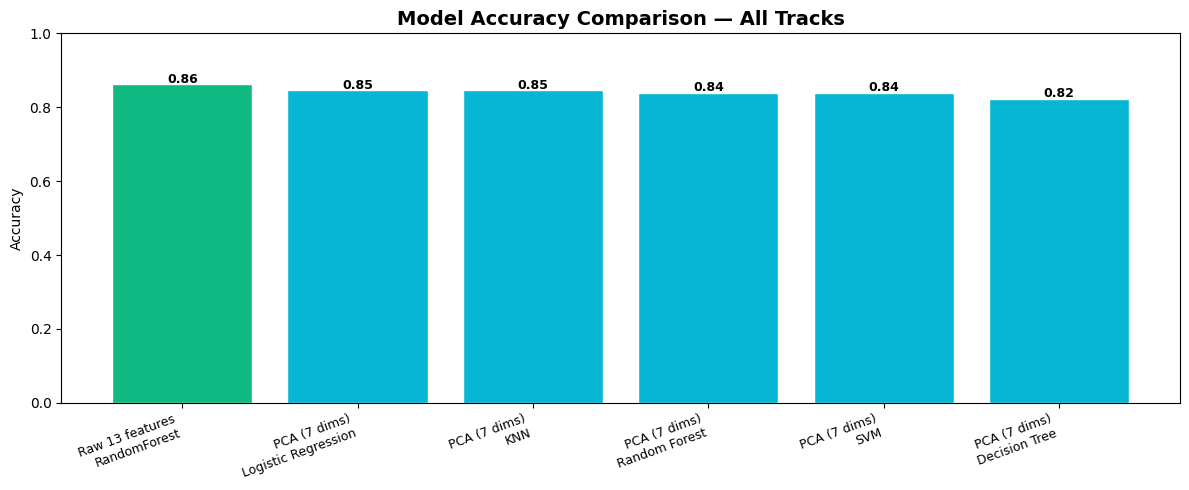

In [14]:
plt.figure(figsize=(12, 5))
labels = [f'{r["Track"]}\n{r["Model"]}' for _, r in all_results.iterrows()]
accs = all_results['Accuracy'].values
colors_bar = ['#10b981' if v == accs.max() else '#06b6d4' for v in accs]

bars = plt.bar(range(len(labels)), accs, color=colors_bar, edgecolor='white')
plt.xticks(range(len(labels)), labels, rotation=20, ha='right', fontsize=9)
plt.title('Model Accuracy Comparison — All Tracks', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.2f}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15: Visualization — Precision, Recall & F1-Score
**Grouped bar chart** comparing all 3 metrics across all models.

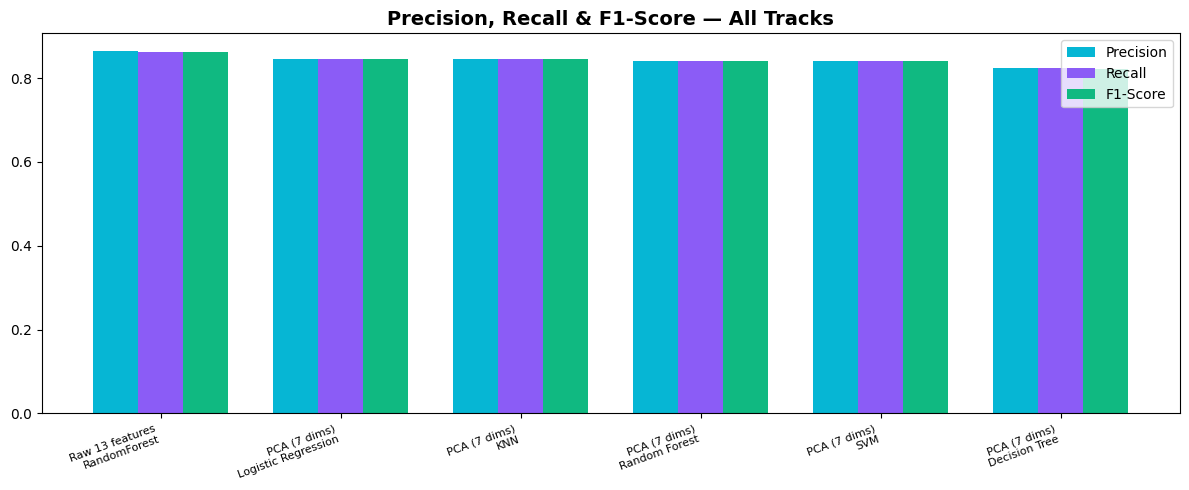

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(all_results))
width = 0.25
ax.bar(x - width, all_results['Precision'], width, label='Precision', color='#06b6d4')
ax.bar(x, all_results['Recall'], width, label='Recall', color='#8b5cf6')
ax.bar(x + width, all_results['F1 Score'], width, label='F1-Score', color='#10b981')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_title('Precision, Recall & F1-Score — All Tracks', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('prf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 16: Visualization — Confusion Matrix (Best Model)
**What it shows:**  
- **TN** = Correctly predicted no disease  
- **FP** = False alarm (predicted disease, actually healthy)  
- **FN** = Missed disease (predicted healthy, actually has disease)  
- **TP** = Correctly predicted disease

CONFUSION MATRIX — Raw 13 features / RandomForest
                Predicted
                No    Yes
Actual  No    |  69    16  | Specificity: 81.2%
        Yes   |   9    87  | Sensitivity: 90.6%
                Accuracy: 86.2%


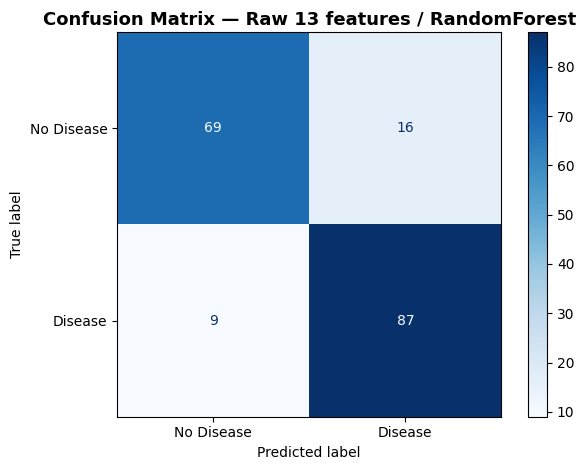

In [16]:
best_track = best_row['Track']
best_model_name = best_row['Model']

if best_track == 'Raw 13 features':
    y_pred_best = y_pred_raw
    cm_best = confusion_matrix(y_test, y_pred_raw)
else:
    best_obj = best_models_pca[best_model_name]
    y_pred_best = best_obj.predict(X_test_pca)
    cm_best = confusion_matrix(y_test, y_pred_best)

tn, fp, fn, tp = cm_best.ravel()
total = tn + fp + fn + tp
print('='*50)
print(f'CONFUSION MATRIX — {best_track} / {best_model_name}')
print('='*50)
print(f'                Predicted')
print(f'                No    Yes')
print(f'Actual  No    | {tn:3d}   {fp:3d}  | Specificity: {tn/(tn+fp)*100:.1f}%')
print(f'        Yes   | {fn:3d}   {tp:3d}  | Sensitivity: {tp/(tp+fn)*100:.1f}%')
print(f'                Accuracy: {(tn+tp)/total*100:.1f}%')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                              display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — {best_track} / {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 17: Save & Download Artifacts
Saves the best model, scaler, PCA, columns, metrics, and all visualizations — then downloads them automatically.

In [17]:
if best_track == 'Raw 13 features':
    final_model = rf_raw
    print('Saving: Raw RandomForest (no scaler/PCA needed)')
else:
    final_model = best_models_pca[best_model_name]
    print(f'Saving: PCA pipeline with {best_model_name}')

with open('Heart_model', 'wb') as f:
    pickle.dump(final_model, f)
with open('columns.json', 'w') as f:
    json.dump({'data_columns': [col.lower() for col in feature_names]}, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

model_info = {
    'model_name': f'{best_track} / {best_model_name}',
    'accuracy': best_row['Accuracy'],
    'precision': best_row['Precision'],
    'recall': best_row['Recall'],
    'f1_score': best_row['F1 Score'],
    'pca_used': bool(best_track != 'Raw 13 features')
}
with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
all_results.to_csv('model_comparison.csv', index=False)

print(f'\n{"="*60}')
print('DEPLOYED MODEL SUMMARY')
print(f'{"="*60}')
print(f'Track      : {best_track}')
print(f'Model      : {best_model_name}')
print(f'Accuracy   : {best_row["Accuracy"]}')
print(f'F1-Score   : {best_row["F1 Score"]}')
print(f'PCA Used   : {model_info["pca_used"]}')

print(f'\nDownloading {14} files...')
artifacts = [
    'Heart_model', 'scaler.pkl', 'pca_model.pkl',
    'columns.json', 'model_info.json', 'model_comparison.csv',
    'target_distribution.png', 'feature_distributions.png',
    'feature_boxplots.png', 'categorical_distributions.png',
    'correlation_heatmap.png', 'accuracy_comparison.png',
    'prf_comparison.png', 'confusion_matrix.png'
]
for fname in artifacts:
    files.download(fname)

print('\nDone! Copy these files into server/artifacts/ and clint/visualizations/')

Saving: Raw RandomForest (no scaler/PCA needed)

DEPLOYED MODEL SUMMARY
Track      : Raw 13 features
Model      : RandomForest
Accuracy   : 0.8619
F1-Score   : 0.8613
PCA Used   : False



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Copy these files into server/artifacts/ and clint/visualizations/
